<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2025/blob/main/202510_FORM8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diseño Factorial 2^k - FORM8**

# **Experimento 2^5 no replicado - Ejemplo, pág. 199**
## **1. Ejemplo integrador**
*En una planta donde se fabrican semiconductores se quiere mejorar el rendimiento del proceso vía diseño de experimentos. De acuerdo con la experiencia del grupo de mejora, los factores que podrían tener mayor influencia sobre la variable de respuesta (rendimiento), así como los niveles de prueba utilizados son los siguientes:*
- A = Nivel de la abertura (pequeña, grande) = (-1,1).
- B = Tiempo de exposición (20% abajo, 20% arriba)= (-1,1).
- C = Tiempo de revelado (30 seg, 45 seg)= (-1,1).
- D = Dimensión de la máscara (pequeña, grande)= (-1,1).
- E = Tiempo de grabado (14.5 min, 15.5 min)= (-1,1).

*Se decide correr un experimento 25 con una sola corrida o réplica para estudiar estos cinco factores. Se hacen las 32 corridas a nivel proceso.*



## **2. Librerias**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **3. Datos**

## **4. Nuestro DataFrame**

In [ ]:
rendimiento = [7, 9, 34, 55, 16, 20, 40, 60,
                8, 10, 32, 50, 18, 21, 44, 61,
                18, 12, 35, 52, 15, 22, 45, 65,
                6, 10, 30, 53, 15, 20, 41, 63]
datos  = pd.DataFrame({
    'Nivel_abertura': (["-1"] * 1 + ["1"] * 1)*16,
    'Tiempo_exposición': (["-1"] * 2 + ["1"] * 2 ) * 8,
    'Tiempo_revelado': (["-1"] * 4 + ["1"] * 4)*4,
    'Dimensión_máscara': (["-1"] * 8 + ["1"] * 8 ) * 2,
    'Tiempo_grabado': ["-1"] * 16 + ["1"] * 16,
    'rendimiento': rendimiento
})

In [ ]:
datos

,Nivel_abertura,Tiempo_exposición,Tiempo_revelado,Dimensión_máscara,Tiempo_grabado,rendimiento
0,-1,-1,-1,-1,-1,7
1,1,-1,-1,-1,-1,9
2,-1,1,-1,-1,-1,34
3,1,1,-1,-1,-1,55
4,-1,-1,1,-1,-1,16
5,1,-1,1,-1,-1,20
6,-1,1,1,-1,-1,40
7,1,1,1,-1,-1,60
8,-1,-1,-1,1,-1,8
9,1,-1,-1,1,-1,10


In [ ]:
import pandas as pd
import numpy as np

# tus datos:
rendimiento = [7, 9, 34, 55, 16, 20, 40, 60,
               8, 10, 32, 50, 18, 21, 44, 61,
               18, 12, 35, 52, 15, 22, 45, 65,
               6, 10, 30, 53, 15, 20, 41, 63]

datos = pd.DataFrame({
    'Nivel_abertura': (["-1"] * 1 + ["1"] * 1)*16,
    'Tiempo_exposición': (["-1"] * 2 + ["1"] * 2 ) * 8,
    'Tiempo_revelado': (["-1"] * 4 + ["1"] * 4)*4,
    'Dimensión_máscara': (["-1"] * 8 + ["1"] * 8 ) * 2,
    'Tiempo_grabado': ["-1"] * 16 + ["1"] * 16,
    'rendimiento': rendimiento
})

# Convertir a valores numéricos
for factor in ['Nivel_abertura', 'Tiempo_exposición', 'Tiempo_revelado', 'Dimensión_máscara', 'Tiempo_grabado']:
    datos[factor] = datos[factor].astype(int)


In [ ]:
N = len(datos)
half = N / 2

efectos = {}
for factor in ['Nivel_abertura', 'Tiempo_exposición', 'Tiempo_revelado', 'Dimensión_máscara', 'Tiempo_grabado']:
    efectos[factor] = (datos[factor] * datos['rendimiento']).sum() / half

efectos


{'Nivel_abertura': np.float64(11.1875),
 'Tiempo_exposición': np.float64(33.3125),
 'Tiempo_revelado': np.float64(9.0625),
 'Dimensión_máscara': np.float64(-1.4375),
 'Tiempo_grabado': np.float64(1.0625)}

# **5. Box_PLot**

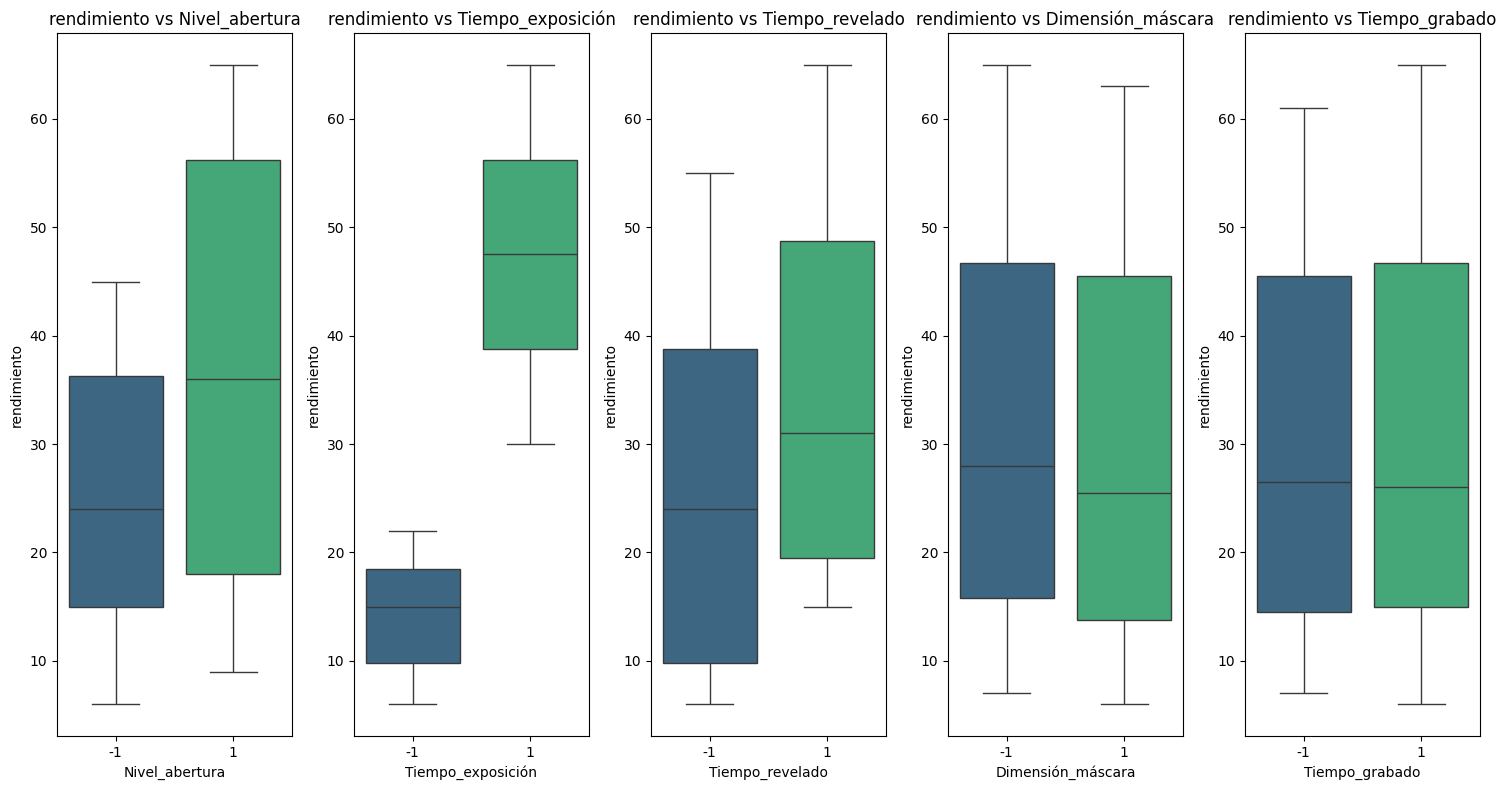

In [ ]:
fig, axs = plt.subplots(1, 5, figsize=(15, 8))
factors = ['Nivel_abertura', 'Tiempo_exposición', 'Tiempo_revelado', 'Dimensión_máscara', 'Tiempo_grabado']
for i, factor in enumerate(factors):
    axs[i].set_title(f'rendimiento vs {factor}')
    sns.boxplot(x=factor, y="rendimiento", data=datos, ax=axs[i], hue=factor, palette='viridis', legend=False)

plt.tight_layout()
plt.show()

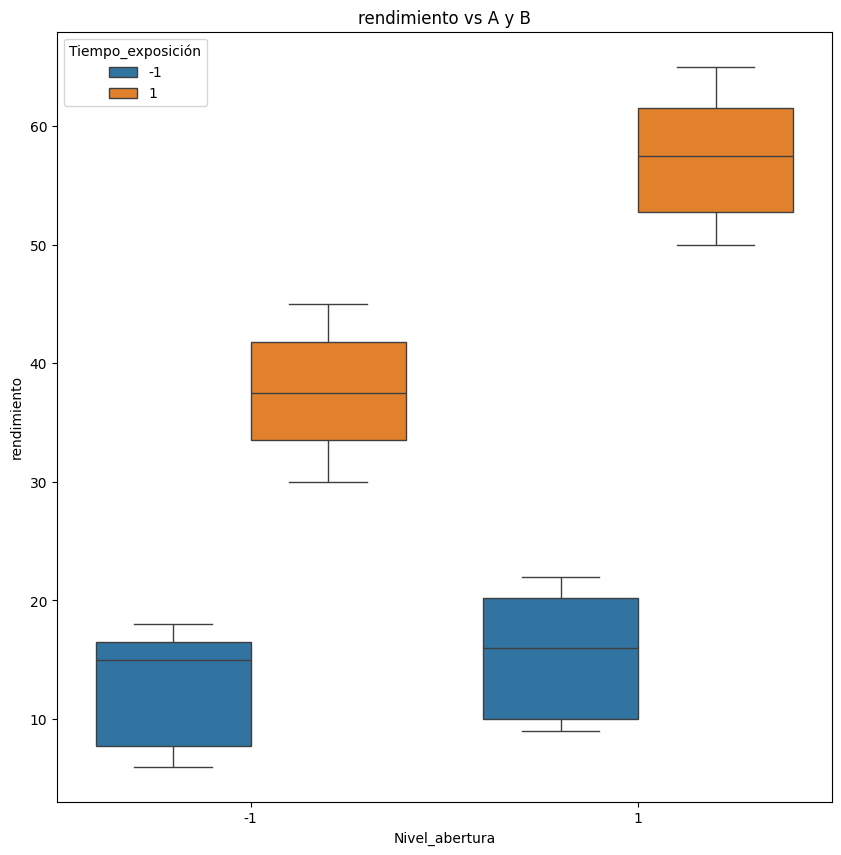

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.set_title('rendimiento vs A y B')
sns.boxplot(x="Nivel_abertura", y="rendimiento", hue='Tiempo_exposición', data=datos,
             ax=ax);

<Axes: title={'center': 'rendimiento vs A y C'}, xlabel='Nivel_abertura', ylabel='rendimiento'>

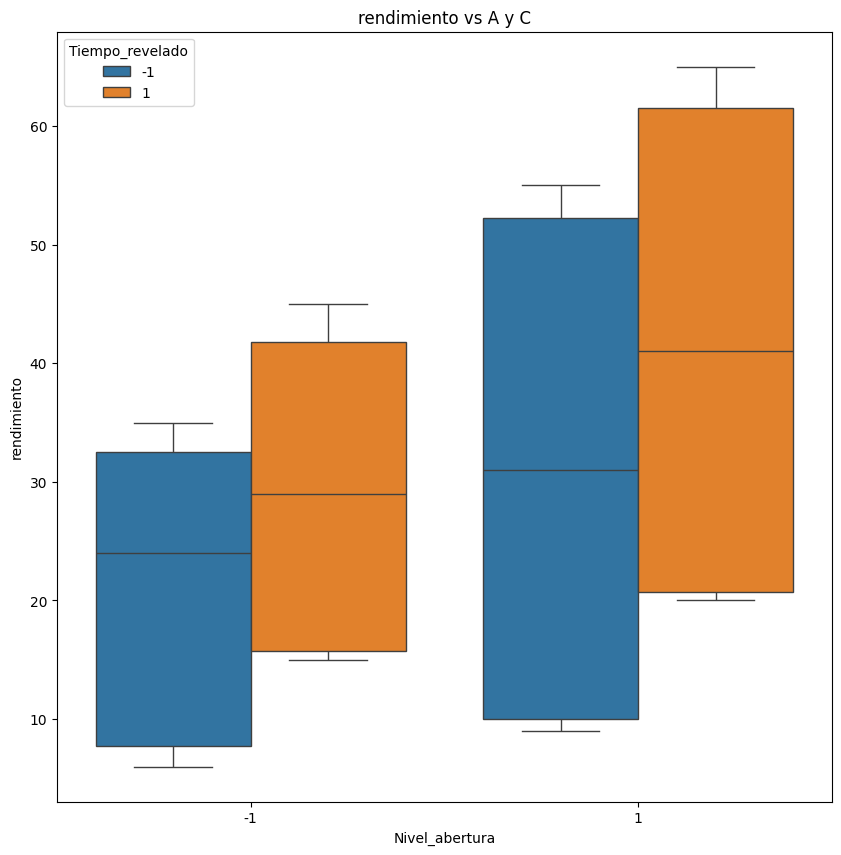

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.set_title('rendimiento vs A y C')
sns.boxplot(x="Nivel_abertura", y="rendimiento", hue='Tiempo_revelado',data=datos,               ax=ax)

# **6. Graficos de interacción**

In [ ]:
from statsmodels.graphics.factorplots import interaction_plot

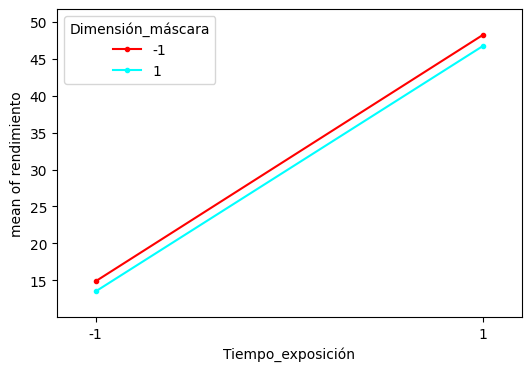

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
fig = interaction_plot(
    x        = datos.Tiempo_exposición,
    trace    = datos.Dimensión_máscara,
    response = datos.rendimiento,
    ax       = ax,
)

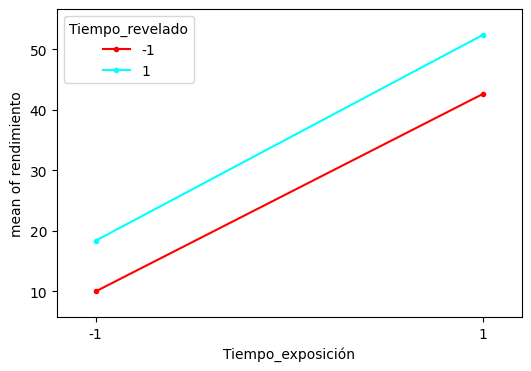

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
fig = interaction_plot(
    x        = datos.Tiempo_exposición,
    trace    = datos.Tiempo_revelado,
    response = datos.rendimiento,
    ax       = ax,
)

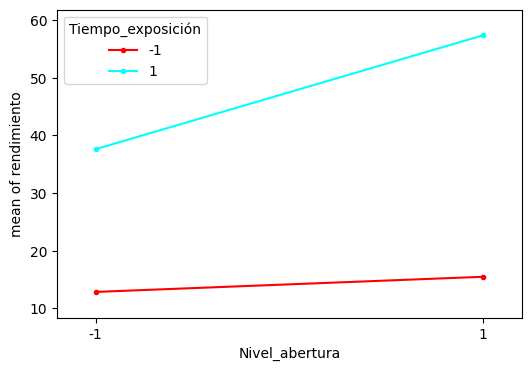

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
fig = interaction_plot(
    x        = datos.Nivel_abertura,
    trace    = datos.Tiempo_exposición,
    response = datos.rendimiento,
    ax       = ax,
)

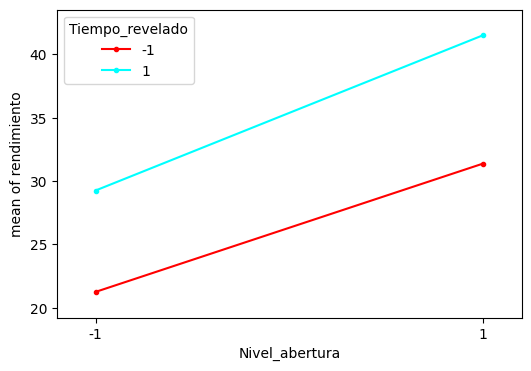

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
fig = interaction_plot(
    x        = datos.Nivel_abertura,
    trace    = datos.Tiempo_revelado,
    response = datos.rendimiento,
    ax       = ax,
)

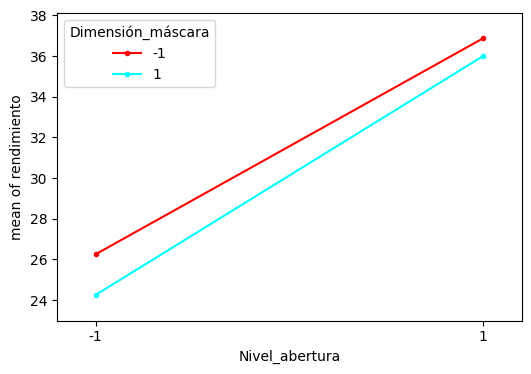

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
fig = interaction_plot(
    x        = datos.Nivel_abertura,
    trace    = datos.Dimensión_máscara,
    response = datos.rendimiento,
    ax       = ax,
)

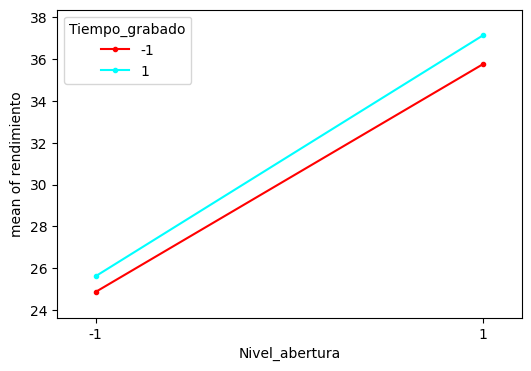

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
fig = interaction_plot(
    x        = datos.Nivel_abertura,
    trace    = datos.Tiempo_grabado,
    response = datos.rendimiento,
    ax       = ax,
)

# **7. No es posible el anova con todos los efectos - Los Efectos de Orden 3 en adelante no son significativos**

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# **a. Anova con los Efectos Principales y las Interacciones Dobles**

In [ ]:
modelo1 = ols("rendimiento ~ (Nivel_abertura+Tiempo_exposición+Tiempo_revelado+Dimensión_máscara+Tiempo_grabado)**2", data = datos).fit()
anova_result = sm.stats.anova_lm(modelo1, typ=1)
print (anova_result)

                                       df      sum_sq      mean_sq  \
Nivel_abertura                        1.0  1001.28125  1001.281250   
Tiempo_exposición                     1.0  8877.78125  8877.781250   
Tiempo_revelado                       1.0   657.03125   657.031250   
Dimensión_máscara                     1.0    16.53125    16.531250   
Tiempo_grabado                        1.0     9.03125     9.031250   
Nivel_abertura:Tiempo_exposición      1.0   586.53125   586.531250   
Nivel_abertura:Tiempo_revelado        1.0     9.03125     9.031250   
Nivel_abertura:Dimensión_máscara      1.0     2.53125     2.531250   
Nivel_abertura:Tiempo_grabado         1.0     0.78125     0.781250   
Tiempo_exposición:Tiempo_revelado     1.0     3.78125     3.781250   
Tiempo_exposición:Dimensión_máscara   1.0     0.03125     0.031250   
Tiempo_exposición:Tiempo_grabado      1.0     0.03125     0.031250   
Tiempo_revelado:Dimensión_máscara     1.0    16.53125    16.531250   
Tiempo_revelado:Tiem

In [ ]:
modelo2 = sm.OLS.from_formula('rendimiento ~ (Nivel_abertura+Tiempo_exposición+Tiempo_revelado+Dimensión_máscara+Tiempo_grabado)**2', data=datos).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:            rendimiento   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     116.9
Date:                Fri, 03 Oct 2025   Prob (F-statistic):           1.88e-13
Time:                        21:42:25   Log-Likelihood:                -63.993
No. Observations:                  32   AIC:                             160.0
Df Residuals:                      16   BIC:                             183.4
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [ ]:
# Calculate the effects
# The coefficients from the OLS model correspond to half of the effect for coded variables (-1, 1)
effects = modelo1.params * 2

# Create a table to display all effects
t_all_effects = Texttable()
t_all_effects.add_rows([['Factor/Interaction', 'Effect']])

for param, effect in effects.items():
    if param != 'Intercept': # Exclude the intercept
        t_all_effects.add_rows([[param, round(effect, 3)]])

print("Table of All Effects:")
print(t_all_effects.draw())

Table of All Effects:
+--------------------------------------------+-------+
| Dimensión_máscara[T.1]:Tiempo_grabado[T.1] | -7.25 |
+============================================+=======+
+--------------------------------------------+-------+


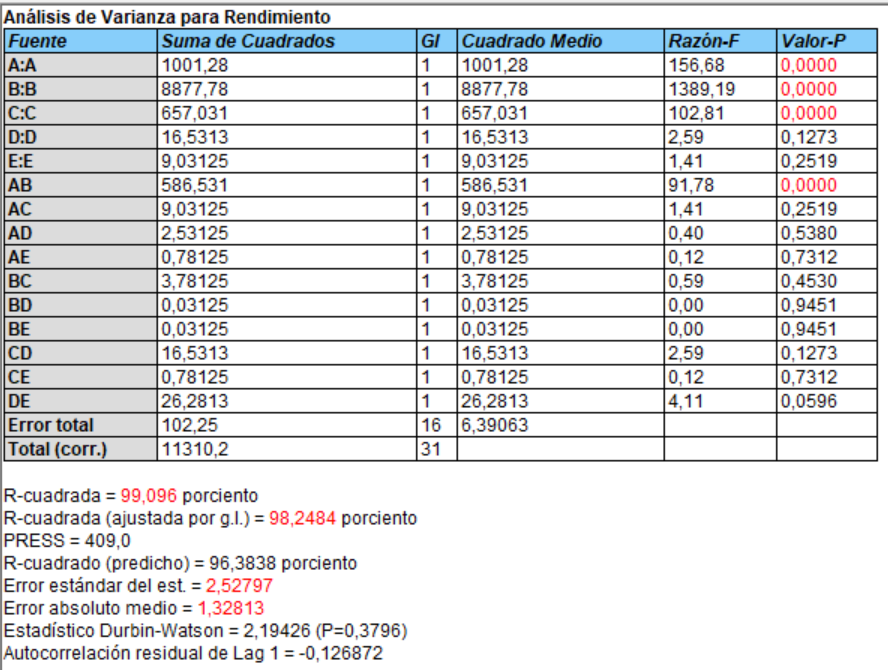

# **b. Efectos Principales**

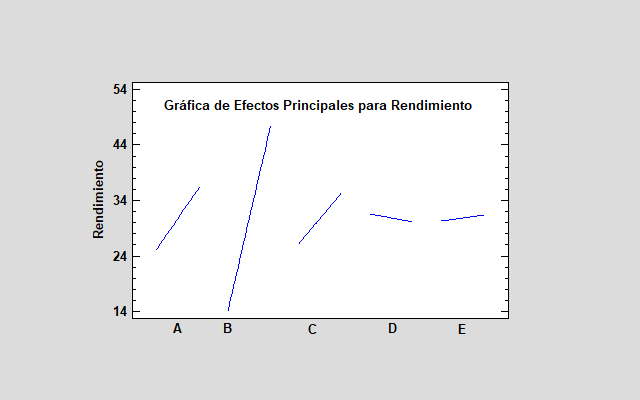

# **c. Interacciones Dobles**

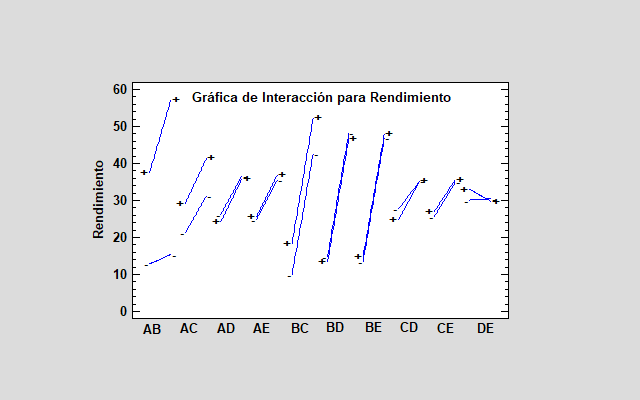

## **d. Encontrando el óptimo**

In [ ]:
modelo2.params

,0
Intercept,9.4375
Nivel_abertura[T.1],0.6875
Tiempo_exposición[T.1],24.1875
Tiempo_revelado[T.1],6.1875
Dimensión_máscara[T.1],-1.5625
Tiempo_grabado[T.1],2.9375
Nivel_abertura[T.1]:Tiempo_exposición[T.1],17.1250
Nivel_abertura[T.1]:Tiempo_revelado[T.1],2.1250
Nivel_abertura[T.1]:Dimensión_máscara[T.1],1.1250
Nivel_abertura[T.1]:Tiempo_grabado[T.1],0.6250


In [ ]:
!pip install texttable &>/dev/null
from texttable import Texttable

t1 = Texttable()
b0, b1, b2, b3, b4, b5, b12, b13, b14, b15, b23, b24, b25, b34, b35, b45, = modelo2.params
# Tabla Resumen

t1.add_rows([['Parametro = bi','valor de bi para el modelo 1' ],
           ['b0',	b0],
           ['b1',	b1],
           ['b2',	b2],
           ['b3',	b3],
           ['b4',	b4],
           ['b5',	b5],
           ['b12',b12],
           ['b13',b13],
           ['b14',b14],
           ['b15',b15],
           ['b23',b23],
           ['b24',b24],
           ['b25',b25],
           ['b34',b34],
           ['b35',b35],
           ['b45',b45]])
print(t1.draw())

+----------------+------------------------------+
| Parametro = bi | valor de bi para el modelo 1 |
+================+==============================+
| b0             | 9.437                        |
+----------------+------------------------------+
| b1             | 0.687                        |
+----------------+------------------------------+
| b2             | 24.187                       |
+----------------+------------------------------+
| b3             | 6.187                        |
+----------------+------------------------------+
| b4             | -1.563                       |
+----------------+------------------------------+
| b5             | 2.937                        |
+----------------+------------------------------+
| b12            | 17.125                       |
+----------------+------------------------------+
| b13            | 2.125                        |
+----------------+------------------------------+
| b14            | 1.125                        |


In [ ]:
from scipy.optimize import minimize

# Define la función que deseas maximizar se antepone el signo (-)
def funcion(x):
    return -(9.437 + 0.687*x[0] + 24.187*x[1] + 6.187*x[2] - 1.563*x[3] + 2.937*x[4] + 17.125*x[0]*x[1] + 2.125*x[0]*x[2] + 1.125*x[0]*x[3] + 0.625*x[0]*x[4] + 1.375*x[1]*x[2] - 0.125*x[1]*x[3] - 0.125*x[1]*x[4]+ 2.875*x[2]*x[3]- 0.625*x[2]*x[4] - 3.625*x[3]*x[4])

# Define las restricciones para x
def variables(x):
    return x[0], x[1], x[2], x[3], x[4]

# Definir las restricciones de límite para x
restricciones = [(-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1)]

# Suprimir la salida de la optimización
res = minimize(funcion, [0, 0, 0, 0, 0], method='SLSQP', constraints={'type':'ineq', 'fun': variables}, bounds=restricciones)

# Imprimir el resultado
print("Resultado óptimo:")
print("x:", res.x)
print("Valor Máximo:", -res.fun)  # Como minimizamos el negativo de la función


Resultado óptimo:
x: [9.99999998e-01 9.99999997e-01 9.99999998e-01 1.27861136e-11
 9.99999998e-01]
Valor Máximo: 63.93499981295733


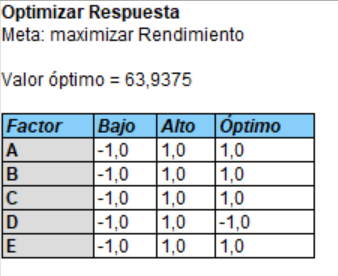

# **8. El anova con todos los efectos - Colapsando el Factor E**

In [ ]:
modelo3 = ols("rendimiento ~ (Nivel_abertura+Tiempo_exposición+Tiempo_revelado+Dimensión_máscara)**2", data = datos).fit()
anova_result = sm.stats.anova_lm(modelo3, typ=1)
print (anova_result)

                                       df      sum_sq      mean_sq  \
Nivel_abertura                        1.0  1001.28125  1001.281250   
Tiempo_exposición                     1.0  8877.78125  8877.781250   
Tiempo_revelado                       1.0   657.03125   657.031250   
Dimensión_máscara                     1.0    16.53125    16.531250   
Nivel_abertura:Tiempo_exposición      1.0   586.53125   586.531250   
Nivel_abertura:Tiempo_revelado        1.0     9.03125     9.031250   
Nivel_abertura:Dimensión_máscara      1.0     2.53125     2.531250   
Tiempo_exposición:Tiempo_revelado     1.0     3.78125     3.781250   
Tiempo_exposición:Dimensión_máscara   1.0     0.03125     0.031250   
Tiempo_revelado:Dimensión_máscara     1.0    16.53125    16.531250   
Residual                             21.0   139.15625     6.626488   

                                               F        PR(>F)  
Nivel_abertura                        151.102852  4.665074e-11  
Tiempo_exposición            

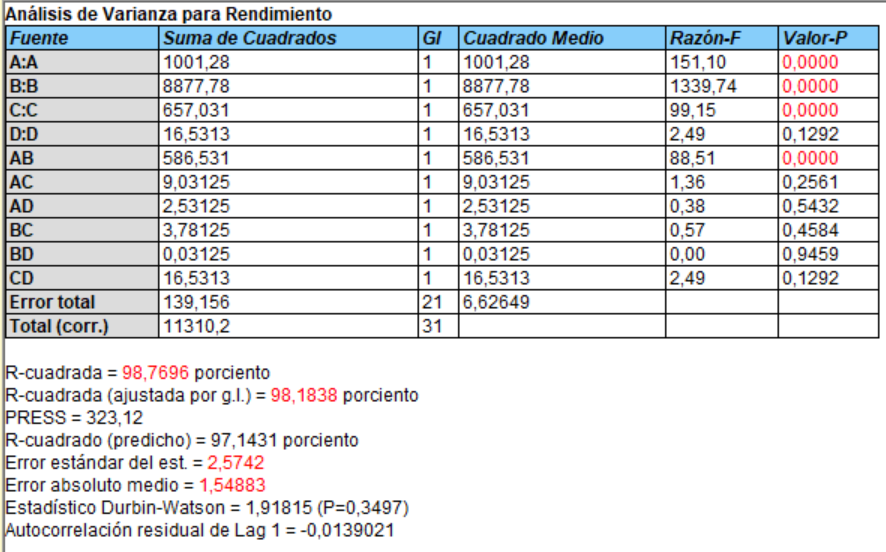

# **9. El anova con todos los efectos - Colapsando otro Factor - el Factor D**

In [ ]:
modelo4 = ols("rendimiento ~ (Nivel_abertura+Tiempo_exposición+Tiempo_revelado)**2", data = datos).fit()
anova_result = sm.stats.anova_lm(modelo4, typ=1)
print (anova_result)

                                     df      sum_sq     mean_sq            F  \
Nivel_abertura                      1.0  1001.28125  1001.28125   143.219203   
Tiempo_exposición                   1.0  8877.78125  8877.78125  1269.841766   
Tiempo_revelado                     1.0   657.03125   657.03125    93.979081   
Nivel_abertura:Tiempo_exposición    1.0   586.53125   586.53125    83.895047   
Nivel_abertura:Tiempo_revelado      1.0     9.03125     9.03125     1.291793   
Tiempo_exposición:Tiempo_revelado   1.0     3.78125     3.78125     0.540855   
Residual                           25.0   174.78125     6.99125          NaN   

                                         PR(>F)  
Nivel_abertura                     7.613839e-12  
Tiempo_exposición                  5.944113e-23  
Tiempo_revelado                    5.977636e-10  
Nivel_abertura:Tiempo_exposición   1.829092e-09  
Nivel_abertura:Tiempo_revelado     2.664954e-01  
Tiempo_exposición:Tiempo_revelado  4.689226e-01  
Residual 

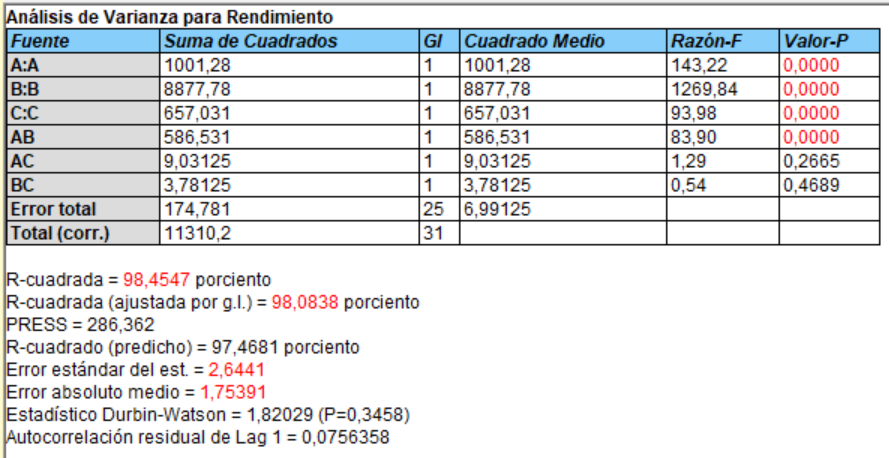

# **10. El Mejor Anova con  los efectos significativos**

In [ ]:
modelo5 = sm.OLS.from_formula('rendimiento ~ (Nivel_abertura + Tiempo_exposición)**2 +  + Tiempo_revelado', data=datos).fit()
print(modelo5.summary())

                            OLS Regression Results                            
Dep. Variable:            rendimiento   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     400.2
Date:                Fri, 03 Oct 2025   Prob (F-statistic):           1.32e-23
Time:                        21:31:27   Log-Likelihood:                -73.703
No. Observations:                  32   AIC:                             157.4
Df Residuals:                      27   BIC:                             164.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [ ]:
modelo6 = ols("rendimiento ~ (Nivel_abertura + Tiempo_exposición)**2 + Tiempo_revelado", data = datos).fit()
anova_result = sm.stats.anova_lm(modelo6, typ=1)
print (anova_result)

                                    df      sum_sq      mean_sq            F  \
Nivel_abertura                     1.0  1001.28125  1001.281250   144.112444   
Tiempo_exposición                  1.0  8877.78125  8877.781250  1277.761619   
Tiempo_revelado                    1.0   657.03125   657.031250    94.565217   
Nivel_abertura:Tiempo_exposición   1.0   586.53125   586.531250    84.418291   
Residual                          27.0   187.59375     6.947917          NaN   

                                        PR(>F)  
Nivel_abertura                    2.459643e-12  
Tiempo_exposición                 2.819698e-24  
Tiempo_revelado                   2.576790e-10  
Nivel_abertura:Tiempo_exposición  8.459071e-10  
Residual                                   NaN  


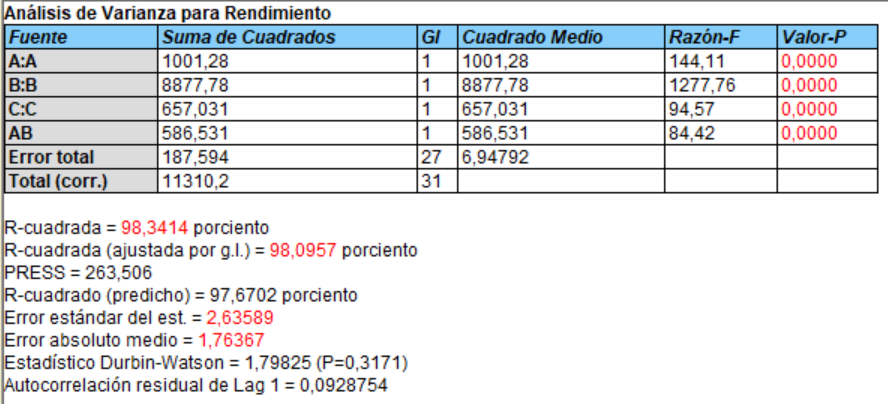

# **11.0 Los Efectos significativos de interacción**

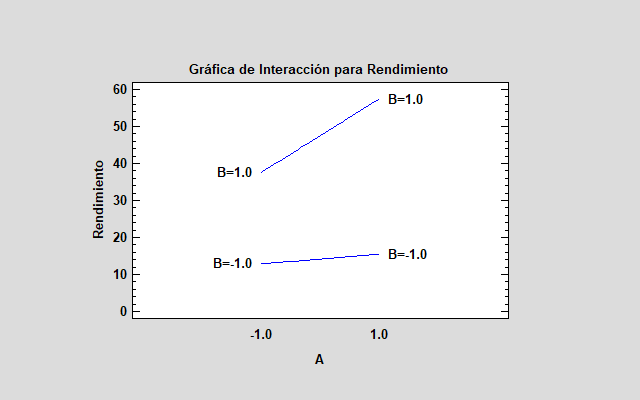

# **12. Los valores de $β_{ij}$ para el modelo5**

In [ ]:
modelo5.params

,0
Intercept,8.34375
Nivel_abertura[T.1],2.62500
Tiempo_exposición[T.1],24.75000
Tiempo_revelado[T.1],9.06250
Nivel_abertura[T.1]:Tiempo_exposición[T.1],17.12500


In [ ]:
#!pip install texttable &>/dev/null
from texttable import Texttable
t2 = Texttable()
b0, b1, b2, b3, b12= modelo5.params
# Tabla Resumen

t2.add_rows([['Parametro = bi','valor de bi para el modelo 2' ],
           ['b0',	b0],
           ['b1',	b1],
           ['b2',	b2],
           ['b3',	b3],
           ['b12',b12]])
print(t2.draw())

+----------------+------------------------------+
| Parametro = bi | valor de bi para el modelo 2 |
+================+==============================+
| b0             | 8.344                        |
+----------------+------------------------------+
| b1             | 2.625                        |
+----------------+------------------------------+
| b2             | 24.750                       |
+----------------+------------------------------+
| b3             | 9.062                        |
+----------------+------------------------------+
| b12            | 17.125                       |
+----------------+------------------------------+


In [ ]:
print(f'El Modelo estimado es ')
print(f'rendimiento = f(x,y,z)= {round(b0,2)}+{round(b1,2)}x+{round(b2,2)}y+{round(b3,2)}z+{round(b12,2)}xy')

El Modelo estimado es 
rendimiento = f(x,y,z)= 8.34+2.62x+24.75y+9.06z+17.12xy


# **13. Maximinzando el rendimiento**

In [ ]:
from scipy.optimize import minimize

# Define la función que deseas maximizar se antepone el signo (-)
def funcion(x):
    return -(8.344 + 2.625*x[0] + 24.750*x[1] + 9.062*x[2] + 17.125*x[0]*x[1])

# Define las restricciones para x
def variables(x):
    return x[0], x[1], x[2]

# Definir las restricciones de límite para x
restricciones = [(-1, 1), (-1, 1), (-1, 1)]

# Suprimir la salida de la optimización
res = minimize(funcion, [0, 0, 0], method='SLSQP', constraints={'type':'ineq', 'fun': variables}, bounds=restricciones)

# Imprimir el resultado
print("Resultado óptimo:")
print("x:", res.x)
print("Valor Máximo:", -res.fun)  # Como minimizamos el negativo de la función


Resultado óptimo:
x: [1. 1. 1.]
Valor Máximo: 61.906


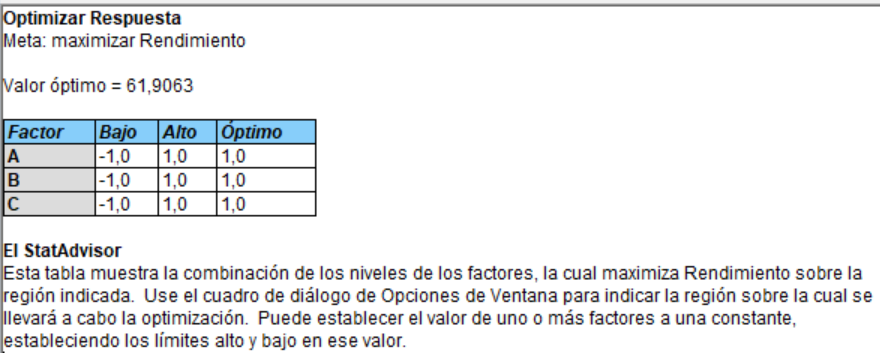